In [4]:
# %% Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [5]:
# %% Some configs
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.size'] = 13



In [ ]:
# %% Load data
df = pd.read_csv('SampleData\SampleData\HomePrices.csv')
x = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']

x, y = np.array(x), np.array(y)
x = sm.add_constant(x)

Text(0, 0.5, 'Price')

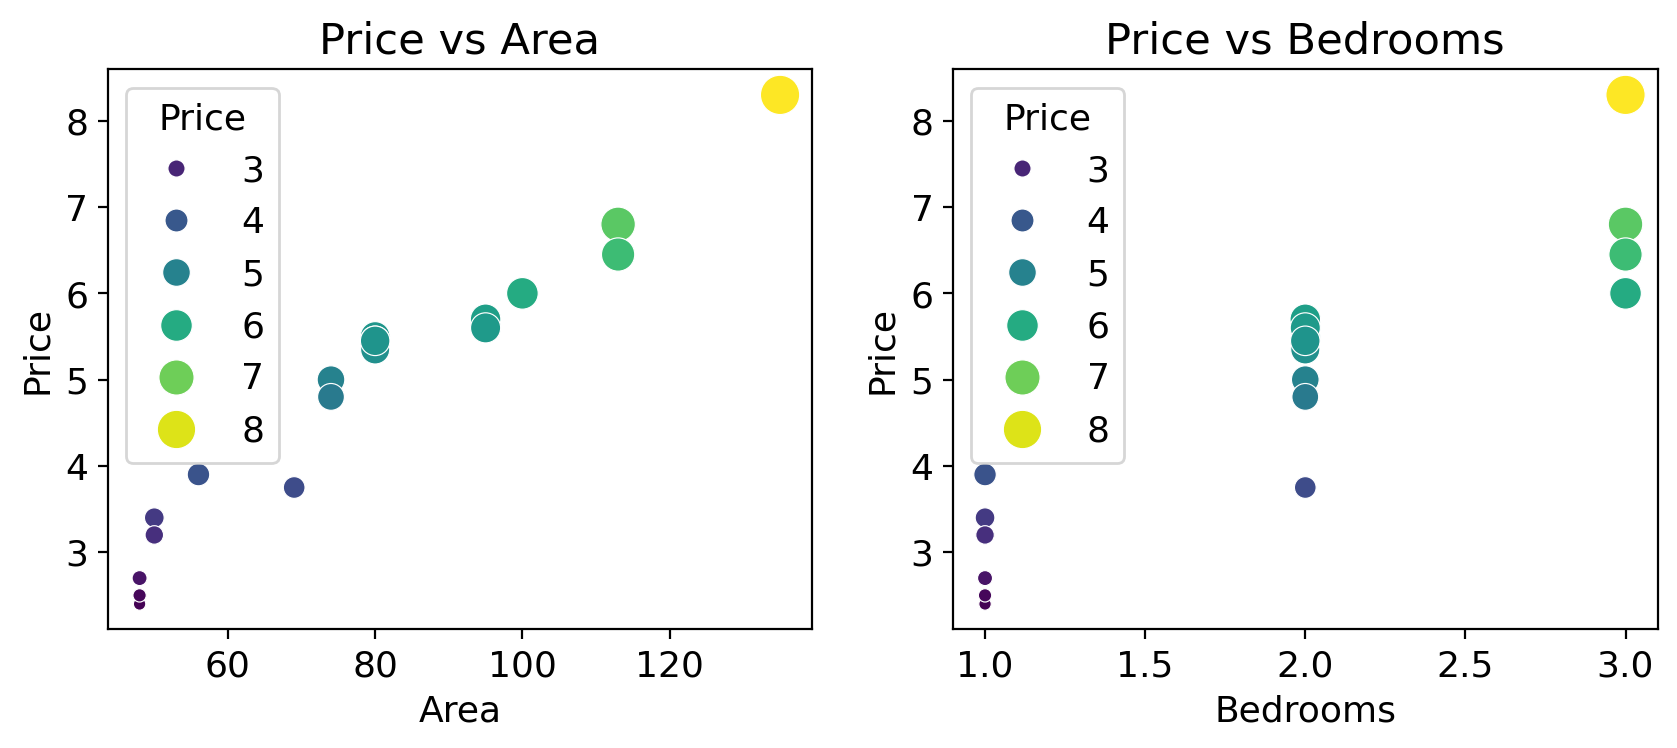

In [8]:
# %% Visualizing data
# Scatter plot for Price vs Area
plt. subplot(2, 2, 1)
sns.scatterplot(data=df, x='Area', y='Price',
    hue='Price', palette='viridis', size='Price', sizes=(20,200))
plt.title('Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')
# Scatter plot for Price vs Bedrooms
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Bedrooms', y='Price',
    hue='Price', palette='viridis', size='Price', sizes=(20,200))
plt.title('Price vs Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')


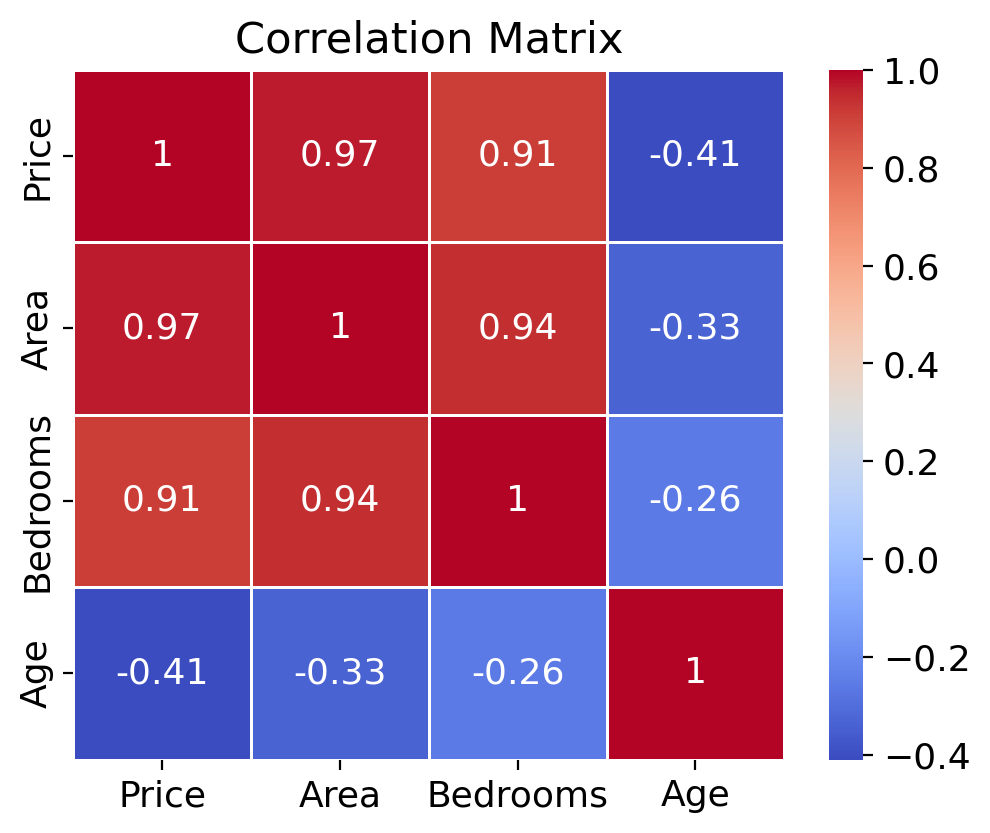

In [9]:

plt.subplot(2,2,4)
sns.heatmap(df.corr(),annot=True,
cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
vif_data= pd.DataFrame()
x_=pd.DataFrame(x,columns=['const','Area','Bedrooms','Age']) # Corrected column names
vif_data["feature"]=x_.columns
vif_data["VIF"]=[variance_inflation_factor(x_.values,i)for i in range(x_.shape[1])]


In [11]:
model= LinearRegression()
rfe= RFE(model,n_features_to_select=2)
fit = rfe.fit(x, y)

print("Feature ranking:")
print(fit.ranking_)

Feature ranking:
[3 2 1 1]


In [12]:
selected_features = [feature for feature, rank in zip(x_.columns,fit.ranking_) if rank==1]
print("Selected features:",selected_features)

Selected features: ['Bedrooms', 'Age']


In [13]:
X_selected= x_[selected_features]
X_selected=sm.add_constant(X_selected)
model_selected=sm.OLS(y, X_selected).fit()

print("Model summary after stepwise selection:")
print(model_selected.summary())

Model summary after stepwise selection:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     48.59
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.60e-07
Time:                        16:35:20   Log-Likelihood:                -16.644
No. Observations:                  19   AIC:                             39.29
Df Residuals:                      16   BIC:                             42.12
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       